# 09 — Robustness Checks

This notebook tests the sensitivity of the key results from notebook 08 (power-law fit → bias → halo mass) to the three main modelling assumptions:

| Check | What varies | Fixed |
|---|---|---|
| **1. Scale cut** | $\theta_{\rm min} \in \{5, 8, 10, 12, 15\}$ arcmin | $\beta=0.8$, Poisson errors |
| **2. Power-law slope** | $\beta \in \{0.6, 0.7, 0.8, 0.9, 1.0\}$ | $\theta_{\rm min}=10$ arcmin, Poisson errors |
| **3. Error model** | Poisson diagonal vs OneCovariance (large scales) | $\beta=0.8$, $\theta_{\rm min}=10$ arcmin |

All fits use the **analytic MLE** (fast, no MCMC) — sufficient for identifying systematic trends.  
The fiducial result from notebook 08: $b = 6.60^{+0.37}_{-0.41}$ at $z_{\rm eff}=1.70$ (θ_min=10 arcmin, β=0.8, Poisson errors).

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.config import cfg, resolve_path
from src.catalog import load_fits_catalog, filter_radec_range
from src.correlation import CorrelationResult
from src.clustering import (
    make_cosmo,
    integral_constraint_factor,
    fit_amplitude,
    limber_h_gamma,
    a0_to_r0,
    linear_bias,
)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

# Fiducial values (from notebook 08)
BETA_FID      = 0.8
GAMMA_FID     = BETA_FID + 1.0
THETA_MIN_FID = 10.0   # arcmin
B_FID         = 6.60   # MCMC median
B_FID_LO      = 6.20
B_FID_HI      = 6.96

print('Project root:', PROJECT_ROOT)
print(f'Fiducial: β={BETA_FID}, θ_min={THETA_MIN_FID} arcmin, b={B_FID:.2f} [{B_FID_LO:.2f},{B_FID_HI:.2f}]')

Project root: /home/k3vinpaul/LRDs
Fiducial: β=0.8, θ_min=10.0 arcmin, b=6.60 [6.20,6.96]


## 2. Load data

In [2]:
# --- 2PACF results (footprint only — detected N=16 is noise-dominated) ---
corr_fp_path = resolve_path(cfg['paths']['corr_dir']) / '2pacf_edf_s_irac_footprint.npz'
cov_fp_path  = resolve_path(cfg['paths']['cov_dir'])  / 'edf_s_irac_footprint/output/cov_matrix.mat'

corr_fp = CorrelationResult.load(str(corr_fp_path))
cov_fp  = np.loadtxt(str(cov_fp_path))   # OneCovariance (15×15)

print(f'Footprint: {corr_fp.n_galaxies:,} galaxies, {corr_fp.valid.sum()} valid bins')
print(f'Bin centres (arcmin): {np.round(corr_fp.theta_arcmin, 2)}')
print(f'OneCovariance shape: {cov_fp.shape}')

Footprint: 1,028 galaxies, 15 valid bins
Bin centres (arcmin): [  0.67   1.     1.5    2.2    3.24   4.82   7.2   10.58  15.68  23.35
  34.45  51.09  75.58 111.39 163.42]
OneCovariance shape: (15, 15)


In [3]:
# --- Cosmology and n(z) ---
cosmo  = make_cosmo(cfg['cosmology'])
sigma8 = cfg['cosmology']['sigma8']
ns     = cfg['cosmology']['ns']
h      = cfg['cosmology']['h']

table  = load_fits_catalog(str(resolve_path(cfg['paths']['raw_catalog'])))
cols   = cfg['columns']
survey = cfg['fields']['edf_s']

sel_fp = np.asarray(table[cols['irac_footprint']], dtype=bool)
t_fp   = table[sel_fp]
t_fp   = filter_radec_range(t_fp, survey['ra_min'], survey['ra_max'],
                             survey['dec_min'], survey['dec_max'],
                             cols['ra'], cols['dec'])
z_fp   = np.asarray(t_fp[cols['redshift']], dtype=float)
z_eff  = float(np.median(z_fp))

# Angular coordinates
theta_rad = np.deg2rad(corr_fp.theta_deg)

# Poisson diagonal covariance (used for most checks)
cov_poisson = np.diag(corr_fp.w_err_poisson**2)
bad = ~np.isfinite(np.diag(cov_poisson))
cov_poisson[bad, bad] = 1e10

print(f'n(z): {len(z_fp)} objects, z_eff = {z_eff:.3f}')

Loaded catalog: /home/k3vinpaul/LRDs/data/raw/LRD_MarIRAC.fits
  Objects : 3,341
  Columns : ['ID', 'RA', 'DEC', 'z', 'z_err', 'MUV', 'MUV_err', 'beta_UV', 'beta_UV_err', 'beta_opt', 'beta_opt_err', 'IRAC-detected', 'IRAC-footprint']
Sky cut [55.0,67.5] × [-52.5,-44.5]: 1,199 / 1,509 objects kept
n(z): 1199 objects, z_eff = 1.703


## 3. Check 1 — Scale cut sensitivity

Vary $\theta_{\rm min} \in \{5, 8, 10, 12, 15\}$ arcmin with fixed $\beta=0.8$ and Poisson errors.  
If the result is robust, $b$ should plateau for $\theta_{\rm min} \gtrsim 8$–10 arcmin (once the 1-halo term is excluded).

In [4]:
BETA  = BETA_FID
GAMMA = GAMMA_FID

# Pre-compute H_gamma and IC (fixed for this check)
H_gamma = limber_h_gamma(z_fp, GAMMA, cosmo, dz=0.05)
ic      = integral_constraint_factor(theta_rad, corr_fp.RR, BETA)

theta_min_values = [5.0, 8.0, 10.0, 12.0, 15.0]
results_scale = []

for theta_min in theta_min_values:
    valid = corr_fp.valid & (corr_fp.theta_arcmin > theta_min)
    n_bins = int(valid.sum())

    if n_bins < 2:
        print(f'θ_min={theta_min:5.1f} arcmin: only {n_bins} bin(s), skip')
        results_scale.append({'theta_min': theta_min, 'n_bins': n_bins,
                               'A0': np.nan, 'r0': np.nan, 'b': np.nan,
                               'A0_err': np.nan, 'r0_err': np.nan, 'b_err': np.nan})
        continue

    A0, sigA0 = fit_amplitude(theta_rad, corr_fp.w, cov_poisson, BETA, ic, valid=valid)
    r0 = a0_to_r0(A0, GAMMA, H_gamma)
    b  = linear_bias(r0, z_eff, GAMMA, sigma8, cosmo)

    # Propagate A0 error → r0 → b (linearised)
    r0_hi = a0_to_r0(A0 + sigA0, GAMMA, H_gamma)
    r0_lo = a0_to_r0(max(A0 - sigA0, 1e-10), GAMMA, H_gamma)
    b_hi  = linear_bias(r0_hi, z_eff, GAMMA, sigma8, cosmo)
    b_lo  = linear_bias(r0_lo,  z_eff, GAMMA, sigma8, cosmo)
    sig_b = 0.5 * abs(b_hi - b_lo)

    results_scale.append({'theta_min': theta_min, 'n_bins': n_bins,
                           'A0': A0, 'r0': r0, 'b': b,
                           'A0_err': sigA0, 'r0_err': abs(r0_hi - r0_lo) / 2,
                           'b_err': sig_b})

    print(f'θ_min={theta_min:5.1f} arcmin  ({n_bins:2d} bins)  '
          f'A₀={A0:.3e}±{sigA0:.2e}  r₀={r0:.2f} Mpc  b={b:.2f}±{sig_b:.2f}')

θ_min=  5.0 arcmin  ( 9 bins)  A₀=1.231e-03±1.34e-04  r₀=25.31 Mpc  b=6.47±0.35
θ_min=  8.0 arcmin  ( 8 bins)  A₀=1.293e-03±1.46e-04  r₀=26.00 Mpc  b=6.63±0.38
θ_min= 10.0 arcmin  ( 8 bins)  A₀=1.293e-03±1.46e-04  r₀=26.00 Mpc  b=6.63±0.38
θ_min= 12.0 arcmin  ( 7 bins)  A₀=1.250e-03±1.65e-04  r₀=25.53 Mpc  b=6.52±0.43
θ_min= 15.0 arcmin  ( 7 bins)  A₀=1.250e-03±1.65e-04  r₀=25.53 Mpc  b=6.52±0.43


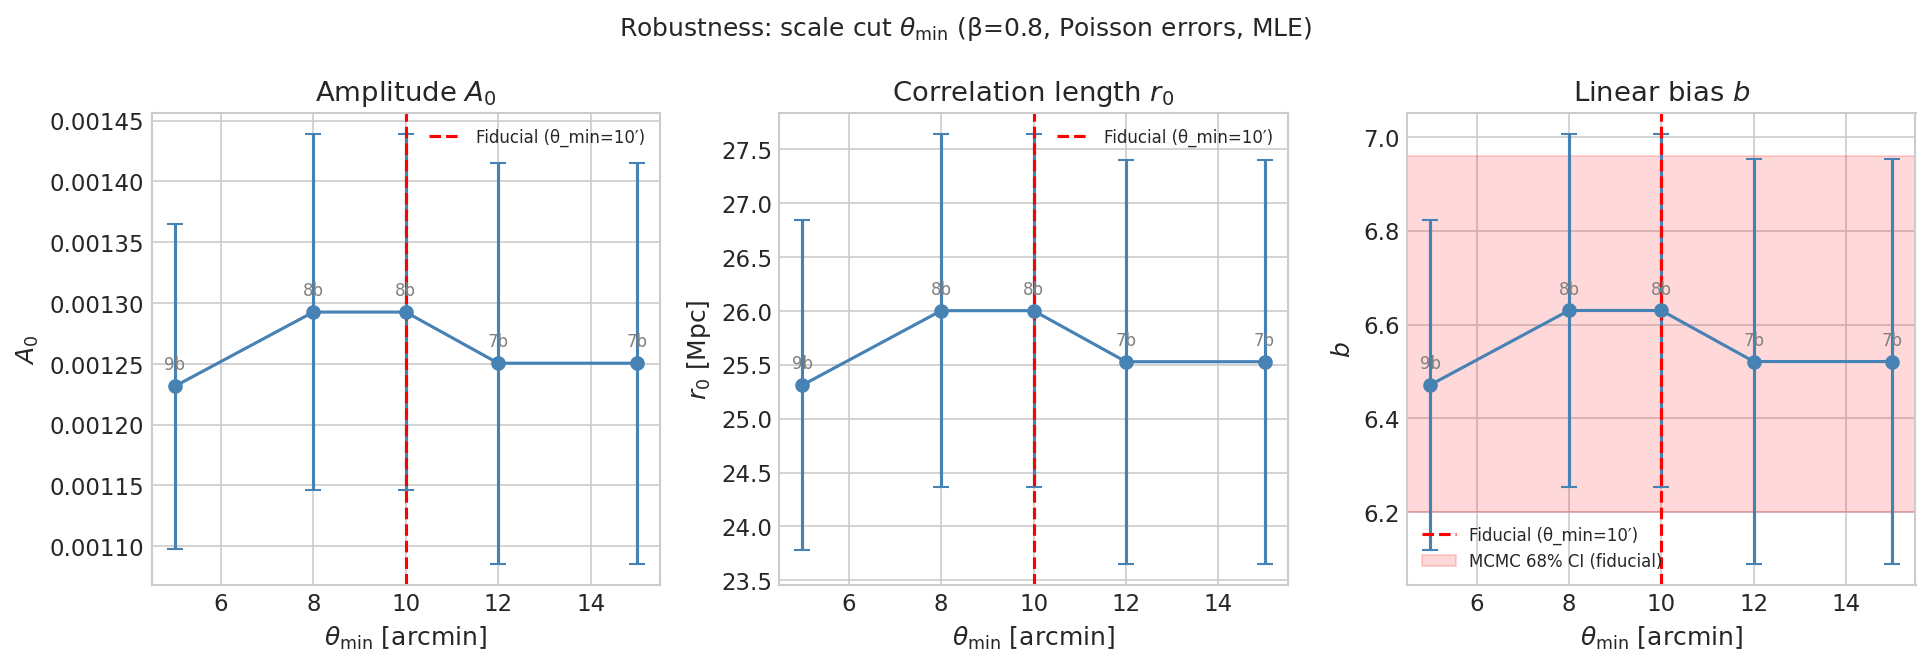


Note: "Nb" labels = number of bins used at each scale cut.


In [5]:
sc = results_scale  # shorthand
x  = np.array([r['theta_min'] for r in sc])
b_vals  = np.array([r['b']     for r in sc])
b_errs  = np.array([r['b_err'] for r in sc])
r0_vals = np.array([r['r0']    for r in sc])
A0_vals = np.array([r['A0']    for r in sc])
nbins   = np.array([r['n_bins'] for r in sc])

ok = np.isfinite(b_vals)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, y, yerr, ylabel, title in [
    (axes[0], A0_vals, [r['A0_err'] for r in sc], r'$A_0$', r'Amplitude $A_0$'),
    (axes[1], r0_vals, [r['r0_err'] for r in sc], r'$r_0$ [Mpc]', r'Correlation length $r_0$'),
    (axes[2], b_vals,  b_errs,                    r'$b$',         r'Linear bias $b$'),
]:
    y    = np.array(y,    dtype=float)
    yerr = np.array(yerr, dtype=float)
    ax.errorbar(x[ok], y[ok], yerr=yerr[ok],
                fmt='o-', color='steelblue', capsize=4, ms=6, lw=1.5)
    # Mark fiducial θ_min
    ax.axvline(THETA_MIN_FID, color='red', ls='--', lw=1.5, label=f'Fiducial (θ_min={THETA_MIN_FID:.0f}′)')
    # Annotate n_bins above each point
    for xi, yi, ni in zip(x[ok], y[ok], nbins[ok]):
        ax.annotate(f'{ni}b', (xi, yi), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color='gray')
    ax.set_xlabel(r'$\theta_{\rm min}$ [arcmin]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

# Add MCMC band on the bias panel
axes[2].axhspan(B_FID_LO, B_FID_HI, alpha=0.15, color='red', label='MCMC 68% CI (fiducial)')
axes[2].legend(fontsize=8)

plt.suptitle(r'Robustness: scale cut $\theta_{\rm min}$ (β=0.8, Poisson errors, MLE)', fontsize=12)
plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'robustness_scale_cut.pdf'),
            bbox_inches='tight')
plt.show()

print('\nNote: "Nb" labels = number of bins used at each scale cut.')

## 4. Check 2 — Power-law slope sensitivity

Vary $\beta \in \{0.6, 0.7, 0.8, 0.9, 1.0\}$ with fixed $\theta_{\rm min}=10$ arcmin and Poisson errors.  
Note: changing $\beta$ also changes $\gamma = \beta+1$ and therefore the Limber integral $H_\gamma$ and the conversion $A_0 \to r_0$.  
A steep $\beta$ means more power on small scales; the Limber geometry factor changes accordingly.

In [6]:
THETA_MIN = THETA_MIN_FID  # fixed
valid_fid = corr_fp.valid & (corr_fp.theta_arcmin > THETA_MIN)
n_bins_fid = int(valid_fid.sum())

beta_values = [0.6, 0.7, 0.8, 0.9, 1.0]
results_beta = []

for beta in beta_values:
    gamma = beta + 1.0

    # Recompute IC and H_gamma for this beta
    ic_b      = integral_constraint_factor(theta_rad, corr_fp.RR, beta)
    H_gamma_b = limber_h_gamma(z_fp, gamma, cosmo, dz=0.05)

    A0, sigA0 = fit_amplitude(theta_rad, corr_fp.w, cov_poisson, beta, ic_b, valid=valid_fid)
    r0 = a0_to_r0(A0, gamma, H_gamma_b)
    b  = linear_bias(r0, z_eff, gamma, sigma8, cosmo)

    # Propagate uncertainty
    r0_hi = a0_to_r0(A0 + sigA0, gamma, H_gamma_b)
    r0_lo = a0_to_r0(max(A0 - sigA0, 1e-10), gamma, H_gamma_b)
    b_hi  = linear_bias(r0_hi, z_eff, gamma, sigma8, cosmo)
    b_lo  = linear_bias(r0_lo, z_eff, gamma, sigma8, cosmo)
    sig_b = 0.5 * abs(b_hi - b_lo)

    results_beta.append({'beta': beta, 'gamma': gamma,
                         'ic': ic_b, 'H_gamma': H_gamma_b,
                         'A0': A0, 'r0': r0, 'b': b,
                         'A0_err': sigA0, 'r0_err': abs(r0_hi - r0_lo) / 2, 'b_err': sig_b})

    print(f'β={beta:.1f}  γ={gamma:.1f}  IC={ic_b:.3f}  H_γ={H_gamma_b:.3e}  '
          f'A₀={A0:.3e}  r₀={r0:.2f} Mpc  b={b:.2f}±{sig_b:.2f}')

β=0.6  γ=1.6  IC=8.789  H_γ=5.448e-06  A₀=4.210e-03  r₀=24.75 Mpc  b=5.63±0.31
β=0.7  γ=1.7  IC=12.857  H_γ=2.331e-06  A₀=2.319e-03  r₀=25.45 Mpc  b=6.12±0.34
β=0.8  γ=1.8  IC=18.940  H_γ=9.970e-07  A₀=1.293e-03  r₀=26.00 Mpc  b=6.63±0.38
β=0.9  γ=1.9  IC=28.128  H_γ=4.266e-07  A₀=7.249e-04  r₀=26.40 Mpc  b=7.16±0.41
β=1.0  γ=2.0  IC=42.162  H_γ=1.825e-07  A₀=4.077e-04  r₀=26.67 Mpc  b=7.69±0.46


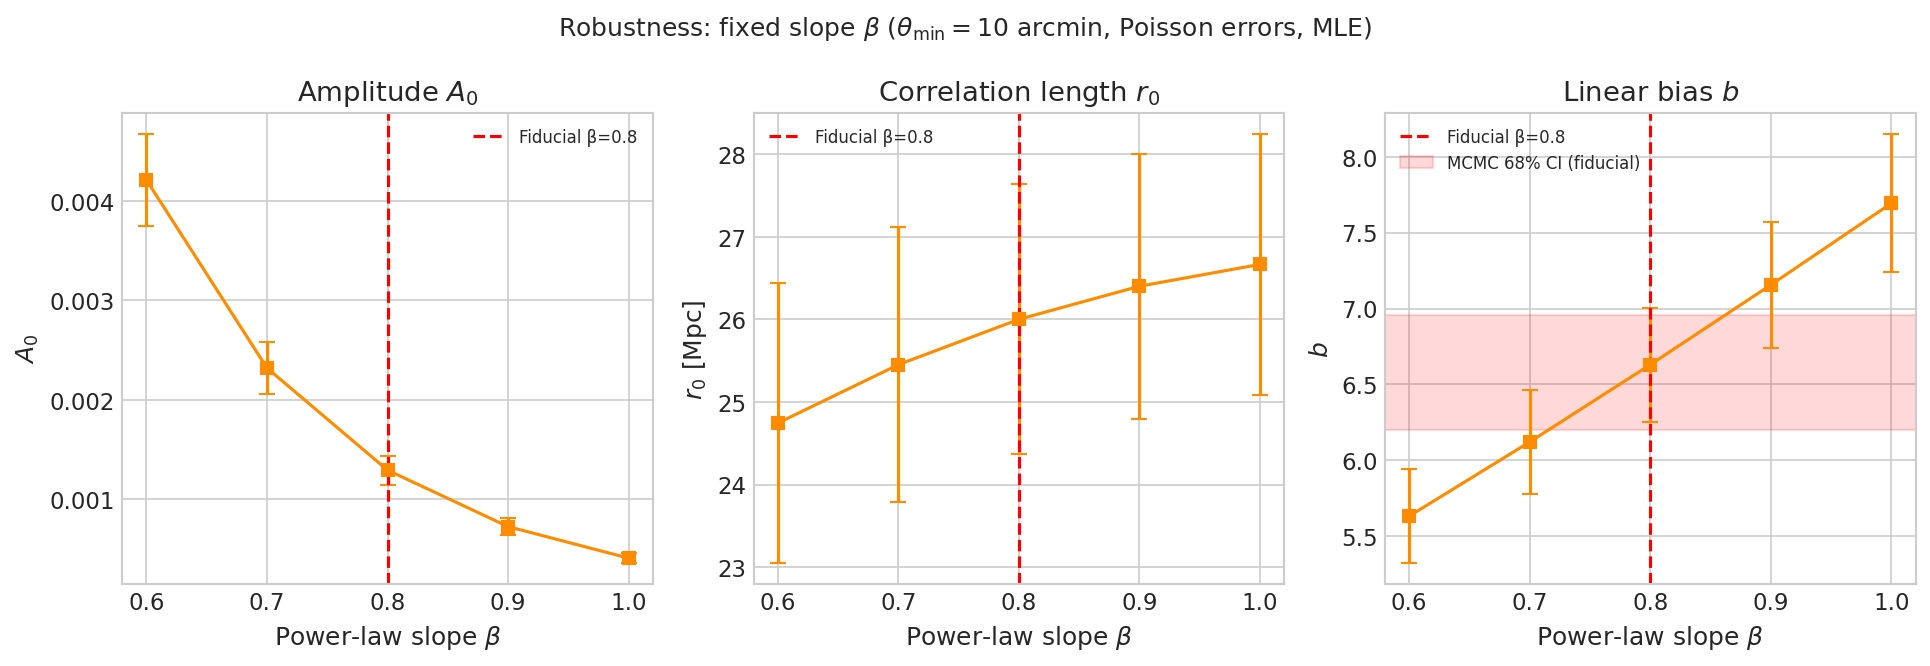

In [7]:
betas   = np.array([r['beta'] for r in results_beta])
b_bvals = np.array([r['b']    for r in results_beta])
b_berrs = np.array([r['b_err'] for r in results_beta])
r0_bvals = np.array([r['r0']  for r in results_beta])
A0_bvals = np.array([r['A0']  for r in results_beta])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, y, yerr, ylabel, title in [
    (axes[0], A0_bvals, [r['A0_err'] for r in results_beta], r'$A_0$', r'Amplitude $A_0$'),
    (axes[1], r0_bvals, [r['r0_err'] for r in results_beta], r'$r_0$ [Mpc]', r'Correlation length $r_0$'),
    (axes[2], b_bvals,  b_berrs,                             r'$b$',         r'Linear bias $b$'),
]:
    y    = np.array(y,    dtype=float)
    yerr = np.array(yerr, dtype=float)
    ok = np.isfinite(y)
    ax.errorbar(betas[ok], y[ok], yerr=yerr[ok],
                fmt='s-', color='darkorange', capsize=4, ms=6, lw=1.5)
    ax.axvline(BETA_FID, color='red', ls='--', lw=1.5, label=f'Fiducial β={BETA_FID}')
    ax.set_xlabel(r'Power-law slope $\beta$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

axes[2].axhspan(B_FID_LO, B_FID_HI, alpha=0.15, color='red', label='MCMC 68% CI (fiducial)')
axes[2].legend(fontsize=8)

plt.suptitle(r'Robustness: fixed slope $\beta$ ($\theta_{\rm min}=10$ arcmin, Poisson errors, MLE)', fontsize=12)
plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'robustness_beta.pdf'),
            bbox_inches='tight')
plt.show()

## 5. Check 3 — Error model comparison

Compare two choices of covariance matrix, both restricted to $\theta > 10$ arcmin:

- **Poisson diagonal**: $C_{ij} = \sigma_{\rm Poisson,i}^2 \, \delta_{ij}$ — robust at all scales, used in notebook 08
- **OneCovariance (large scales only)**: the full Gaussian covariance sub-matrix restricted to $\theta > 10$ arcmin bins — valid in the linear regime

If the two give consistent $A_0$ and $b$, the error model choice does not dominate the systematic budget.

In [8]:
BETA  = BETA_FID
GAMMA = GAMMA_FID
ic      = integral_constraint_factor(theta_rad, corr_fp.RR, BETA)
H_gamma = limber_h_gamma(z_fp, GAMMA, cosmo, dz=0.05)
valid   = corr_fp.valid & (corr_fp.theta_arcmin > THETA_MIN_FID)

# --- Poisson diagonal (fiducial) ---
A0_pois, sig_pois = fit_amplitude(theta_rad, corr_fp.w, cov_poisson, BETA, ic, valid=valid)
r0_pois = a0_to_r0(A0_pois, GAMMA, H_gamma)
b_pois  = linear_bias(r0_pois, z_eff, GAMMA, sigma8, cosmo)

# Propagate
b_pois_hi = linear_bias(a0_to_r0(A0_pois + sig_pois, GAMMA, H_gamma), z_eff, GAMMA, sigma8, cosmo)
b_pois_lo = linear_bias(a0_to_r0(max(A0_pois - sig_pois, 1e-10), GAMMA, H_gamma), z_eff, GAMMA, sigma8, cosmo)

print('=== Poisson diagonal (fiducial) ===')
print(f'  A₀ = {A0_pois:.4e} ± {sig_pois:.4e}')
print(f'  r₀ = {r0_pois:.2f} Mpc')
print(f'  b  = {b_pois:.2f}  [{b_pois_lo:.2f}, {b_pois_hi:.2f}]')

# --- OneCovariance restricted to large-scale bins ---
# Subset the full 15×15 OneCovariance to the valid (large-scale) bins
cov_1hcov = cov_fp.copy()
# Guard against non-positive-definite sub-matrix: add small regularisation
idx = np.where(valid)[0]
sub = cov_1hcov[np.ix_(idx, idx)]
# Check condition number
cond = np.linalg.cond(sub)
print(f'\nOneCovariance sub-matrix (large scales): condition number = {cond:.2e}')
if cond > 1e12:
    print('  Warning: Ill-conditioned — adding regularisation ε=1e-6 × trace / n')
    reg = 1e-6 * np.trace(sub) / len(idx)
    cov_1hcov[np.ix_(idx, idx)] += reg * np.eye(len(idx))

A0_1hcov, sig_1hcov = fit_amplitude(theta_rad, corr_fp.w, cov_1hcov, BETA, ic, valid=valid)
r0_1hcov = a0_to_r0(A0_1hcov, GAMMA, H_gamma)
b_1hcov  = linear_bias(r0_1hcov, z_eff, GAMMA, sigma8, cosmo)

b_1hcov_hi = linear_bias(a0_to_r0(A0_1hcov + sig_1hcov, GAMMA, H_gamma), z_eff, GAMMA, sigma8, cosmo)
b_1hcov_lo = linear_bias(a0_to_r0(max(A0_1hcov - sig_1hcov, 1e-10), GAMMA, H_gamma), z_eff, GAMMA, sigma8, cosmo)

print('\n=== OneCovariance — large scales only ===')
print(f'  A₀ = {A0_1hcov:.4e} ± {sig_1hcov:.4e}')
print(f'  r₀ = {r0_1hcov:.2f} Mpc')
print(f'  b  = {b_1hcov:.2f}  [{b_1hcov_lo:.2f}, {b_1hcov_hi:.2f}]')

=== Poisson diagonal (fiducial) ===
  A₀ = 1.2925e-03 ± 1.4626e-04
  r₀ = 26.00 Mpc
  b  = 6.63  [6.24, 7.00]

OneCovariance sub-matrix (large scales): condition number = 6.51e+01

=== OneCovariance — large scales only ===
  A₀ = 1.4090e-03 ± 1.2444e-04
  r₀ = 27.28 Mpc
  b  = 6.92  [6.61, 7.22]


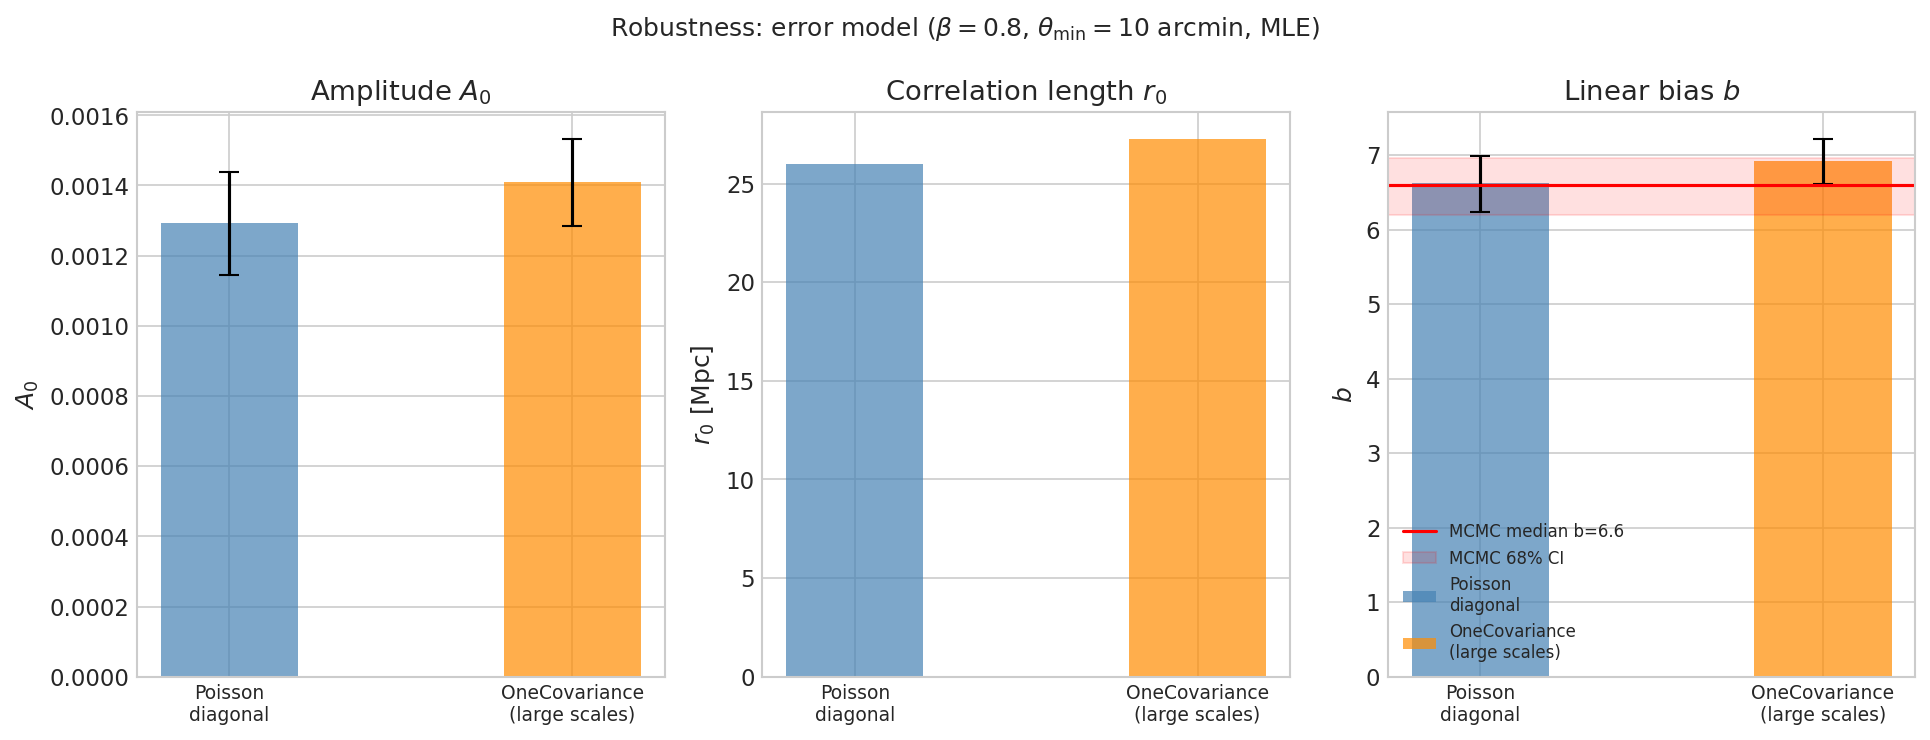

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

labels  = ['Poisson\ndiagonal', 'OneCovariance\n(large scales)']
colors  = ['steelblue', 'darkorange']
A0s     = [A0_pois,  A0_1hcov]
sigA0s  = [sig_pois, sig_1hcov]
r0s     = [r0_pois,  r0_1hcov]
bs      = [b_pois,   b_1hcov]
bs_lo   = [b_pois_lo, b_1hcov_lo]
bs_hi   = [b_pois_hi, b_1hcov_hi]

x_pos = [0, 1]

for ax, vals, errs, lo, hi, ylabel, title in [
    (axes[0], A0s, sigA0s, None, None, r'$A_0$', r'Amplitude $A_0$'),
    (axes[1], r0s, None,   None, None, r'$r_0$ [Mpc]', r'Correlation length $r_0$'),
    (axes[2], bs,  None,   bs_lo, bs_hi, r'$b$', r'Linear bias $b$'),
]:
    for xi, vi, ci, lab in zip(x_pos, vals, colors, labels):
        ax.bar(xi, vi, color=ci, alpha=0.7, width=0.4, label=lab)
        if errs is not None:
            ax.errorbar(xi, vi, yerr=errs[xi], fmt='none', color='black', capsize=5)
        if lo is not None and hi is not None:
            ax.errorbar(xi, vi, yerr=[[vi - lo[xi]], [hi[xi] - vi]],
                        fmt='none', color='black', capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

# Reference line on bias panel
axes[2].axhline(B_FID,   color='red', ls='-',  lw=1.5, label=f'MCMC median b={B_FID}')
axes[2].axhspan(B_FID_LO, B_FID_HI, alpha=0.12, color='red', label='MCMC 68% CI')
axes[2].legend(fontsize=8)

plt.suptitle(r'Robustness: error model ($\beta=0.8$, $\theta_{\rm min}=10$ arcmin, MLE)', fontsize=12)
plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'robustness_error_model.pdf'),
            bbox_inches='tight')
plt.show()

## 6. Summary

In [10]:
print('=' * 72)
print('ROBUSTNESS SUMMARY — IRAC footprint (N=1028, z_eff=1.70)')
print('=' * 72)

print('\n[Check 1] Scale cut sensitivity (β=0.8, Poisson errors):')
print(f'  {"θ_min":>8}  {"N_bins":>6}  {"A0":>12}  {"r0 [Mpc]":>10}  {"b":>8}')
print(f'  {"-"*8}  {"-"*6}  {"-"*12}  {"-"*10}  {"-"*8}')
for r in results_scale:
    if np.isnan(r['b']):
        continue
    fid = ' ← fiducial' if r['theta_min'] == THETA_MIN_FID else ''
    print(f'  {r["theta_min"]:>6.0f}′  {r["n_bins"]:>6}  '
          f'{r["A0"]:>12.3e}  {r["r0"]:>10.2f}  {r["b"]:>8.2f}{fid}')

print('\n[Check 2] Slope sensitivity (θ_min=10 arcmin, Poisson errors):')
print(f'  {"β":>5}  {"γ":>5}  {"A0":>12}  {"r0 [Mpc]":>10}  {"b":>8}')
print(f'  {"-"*5}  {"-"*5}  {"-"*12}  {"-"*10}  {"-"*8}')
for r in results_beta:
    fid = ' ← fiducial' if r['beta'] == BETA_FID else ''
    print(f'  {r["beta"]:>5.1f}  {r["gamma"]:>5.1f}  '
          f'{r["A0"]:>12.3e}  {r["r0"]:>10.2f}  {r["b"]:>8.2f}{fid}')

print('\n[Check 3] Error model (β=0.8, θ_min=10 arcmin):')
print(f'  {"Model":20}  {"A0":>12}  {"r0 [Mpc]":>10}  {"b":>8}')
print(f'  {"-"*20}  {"-"*12}  {"-"*10}  {"-"*8}')
print(f'  {"Poisson diagonal":20}  {A0_pois:>12.3e}  {r0_pois:>10.2f}  {b_pois:>8.2f}  <- fiducial')
print(f'  {"OneCovariance (LS)":20}  {A0_1hcov:>12.3e}  {r0_1hcov:>10.2f}  {b_1hcov:>8.2f}')

print('\n' + '=' * 72)
print('CONCLUSIONS:')

# Scale cut conclusion
b_at_cuts = [r['b'] for r in results_scale if not np.isnan(r['b'])]
b_spread_sc = max(b_at_cuts) - min(b_at_cuts)
print(f'  1. Scale cut: b spans {min(b_at_cuts):.2f}–{max(b_at_cuts):.2f} '
      f'(Δb = {b_spread_sc:.2f}) across all θ_min values.')
print(f'     -> {"STABLE" if b_spread_sc < 2.0 else "SENSITIVE"}: '
      f'systematic from scale cut choice ≈ {b_spread_sc:.1f} (cf. stat. error {B_FID_HI-B_FID_LO:.2f})')

b_betas = [r['b'] for r in results_beta]
b_spread_beta = max(b_betas) - min(b_betas)
print(f'  2. Slope β: b spans {min(b_betas):.2f}–{max(b_betas):.2f} '
      f'(Δb = {b_spread_beta:.2f}) across β=0.6–1.0.')
print(f'     -> {"STABLE" if b_spread_beta < 2.0 else "SENSITIVE"}: '
      f'systematic from fixing β ≈ {b_spread_beta:.1f} (cf. stat. error {B_FID_HI-B_FID_LO:.2f})')

b_diff_cov = abs(b_1hcov - b_pois)
print(f'  3. Error model: Δb = {b_diff_cov:.2f} between Poisson and OneCovariance.')
print(f'     -> {"CONSISTENT" if b_diff_cov < 1.0 else "INCONSISTENT"}: '
      f'error model choice is subdominant.')
print('=' * 72)

ROBUSTNESS SUMMARY — IRAC footprint (N=1028, z_eff=1.70)

[Check 1] Scale cut sensitivity (β=0.8, Poisson errors):
     θ_min  N_bins            A0    r0 [Mpc]         b
  --------  ------  ------------  ----------  --------
       5′       9     1.231e-03       25.31      6.47
       8′       8     1.293e-03       26.00      6.63
      10′       8     1.293e-03       26.00      6.63 ← fiducial
      12′       7     1.250e-03       25.53      6.52
      15′       7     1.250e-03       25.53      6.52

[Check 2] Slope sensitivity (θ_min=10 arcmin, Poisson errors):
      β      γ            A0    r0 [Mpc]         b
  -----  -----  ------------  ----------  --------
    0.6    1.6     4.210e-03       24.75      5.63
    0.7    1.7     2.319e-03       25.45      6.12
    0.8    1.8     1.293e-03       26.00      6.63 ← fiducial
    0.9    1.9     7.249e-04       26.40      7.16
    1.0    2.0     4.077e-04       26.67      7.69

[Check 3] Error model (β=0.8, θ_min=10 arcmin):
  Model      

## 7. Robustness overview plot

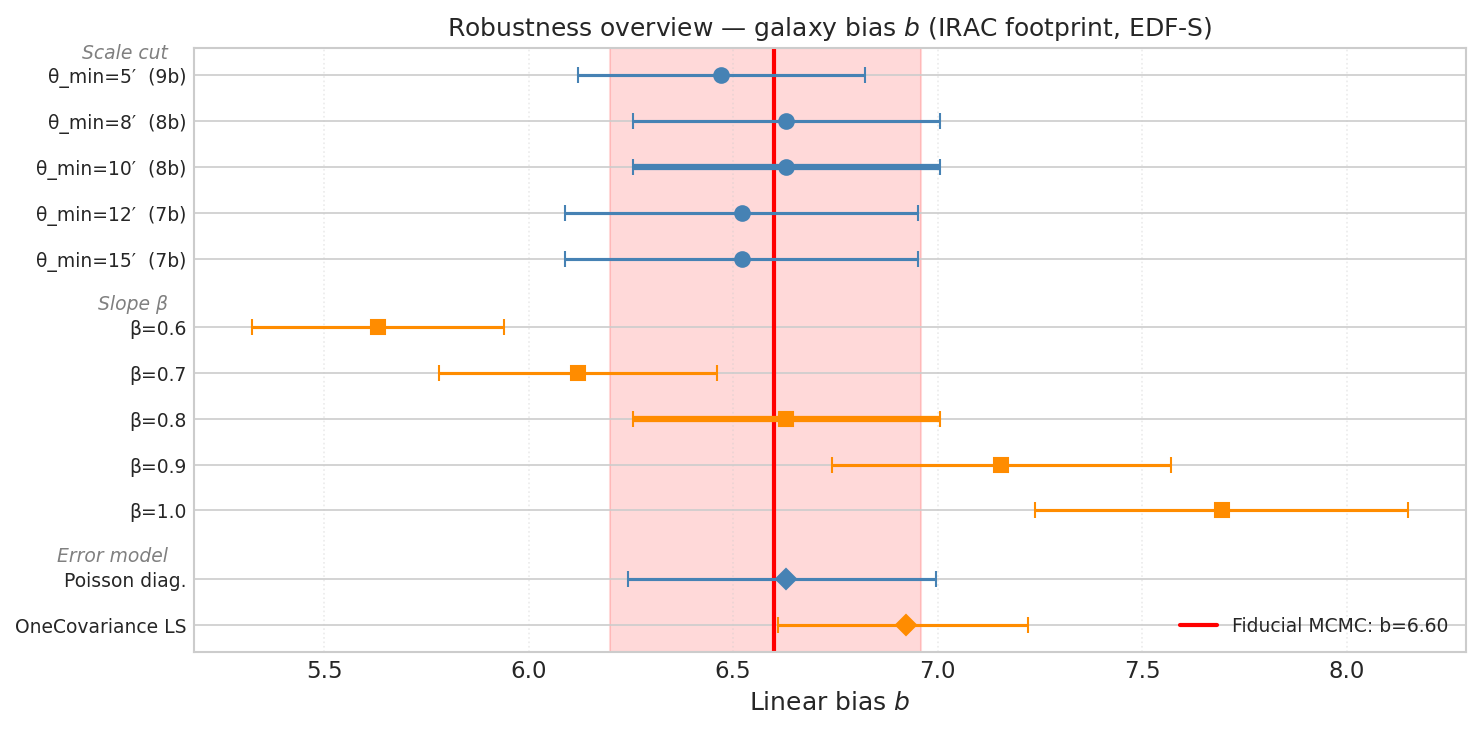

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = 0
yticks, ylabels = [], []

# Fiducial MCMC result (shaded band)
ax.axvspan(B_FID_LO, B_FID_HI, alpha=0.15, color='red', zorder=0)
ax.axvline(B_FID, color='red', ls='-', lw=2, label=f'Fiducial MCMC: b={B_FID:.2f}', zorder=1)

# --- Check 1: scale cut ---
y_pos -= 1
ax.text(-0.02, y_pos + 0.5, 'Scale cut', transform=ax.get_yaxis_transform(),
        ha='right', va='center', fontsize=9, color='gray', style='italic')
for r in results_scale:
    if np.isnan(r['b']):
        continue
    lw = 3 if r['theta_min'] == THETA_MIN_FID else 1.5
    ax.errorbar(r['b'], y_pos, xerr=r['b_err'],
                fmt='o', color='steelblue', ms=7, capsize=4, lw=lw, zorder=3)
    yticks.append(y_pos)
    ylabels.append(f"θ_min={r['theta_min']:.0f}′  ({r['n_bins']}b)")
    y_pos -= 1

# --- Check 2: beta ---
y_pos -= 0.5
ax.text(-0.02, y_pos + 0.5, 'Slope β', transform=ax.get_yaxis_transform(),
        ha='right', va='center', fontsize=9, color='gray', style='italic')
for r in results_beta:
    lw = 3 if r['beta'] == BETA_FID else 1.5
    ax.errorbar(r['b'], y_pos, xerr=r['b_err'],
                fmt='s', color='darkorange', ms=7, capsize=4, lw=lw, zorder=3)
    yticks.append(y_pos)
    ylabels.append(f"β={r['beta']:.1f}")
    y_pos -= 1

# --- Check 3: error model ---
y_pos -= 0.5
ax.text(-0.02, y_pos + 0.5, 'Error model', transform=ax.get_yaxis_transform(),
        ha='right', va='center', fontsize=9, color='gray', style='italic')
for label, bv, blo, bhi, color in [
    ('Poisson diag.',    b_pois,   b_pois_lo,   b_pois_hi,   'steelblue'),
    ('OneCovariance LS', b_1hcov, b_1hcov_lo, b_1hcov_hi, 'darkorange'),
]:
    ax.errorbar(bv, y_pos, xerr=[[bv - blo], [bhi - bv]],
                fmt='D', color=color, ms=7, capsize=4, lw=1.5, zorder=3)
    yticks.append(y_pos)
    ylabels.append(label)
    y_pos -= 1

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel('Linear bias $b$', fontsize=12)
ax.set_title('Robustness overview — galaxy bias $b$ (IRAC footprint, EDF-S)', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', ls=':', alpha=0.4)

plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'robustness_overview.pdf'),
            bbox_inches='tight')
plt.show()

## 8. Free-β fit — 2D χ² grid

Fit both $A_0$ and $\beta$ simultaneously by scanning a 2D grid and evaluating:

$$\chi^2(A_0, \beta) = \bigl[w_{\rm obs} - A_0(\theta^{-\beta} - F(\beta))\bigr]^\top C^{-1} \bigl[w_{\rm obs} - A_0(\theta^{-\beta} - F(\beta))\bigr]$$

where $F(\beta)$ is the integral constraint recomputed for each $\beta$, and $C^{-1}$ is the Poisson diagonal inverse.  
Confidence contours: $\Delta\chi^2 = 2.30$ (68%), $\Delta\chi^2 = 6.17$ (95%) for 2 free parameters.

In [12]:
# Grid setup
N_BETA       = 100
N_A0         = 120
beta_grid    = np.linspace(0.1, 1.5, N_BETA)   # extended: was [0.4, 1.3]
log10A0_grid = np.linspace(-5.0, -1.0, N_A0)
A0_grid      = 10.0**log10A0_grid

# Fixed: Poisson covariance, fiducial scale cut
valid   = corr_fp.valid & (corr_fp.theta_arcmin > THETA_MIN_FID)
C_inv   = np.linalg.inv(cov_poisson[np.ix_(valid, valid)])
w_obs   = corr_fp.w[valid]
theta_v = theta_rad[valid]

# Build 2D chi² surface — outer loop over beta (recomputes IC), inner over A0
chi2_surface = np.full((N_BETA, N_A0), np.inf)

for i, beta in enumerate(beta_grid):
    ic_b     = integral_constraint_factor(theta_rad, corr_fp.RR, beta)
    template = theta_v**(-beta) - ic_b          # model shape, A0 factored out
    for j, A0 in enumerate(A0_grid):
        resid = w_obs - A0 * template
        chi2_surface[i, j] = float(resid @ C_inv @ resid)

# Best-fit point
imin, jmin   = np.unravel_index(np.argmin(chi2_surface), chi2_surface.shape)
beta_best    = beta_grid[imin]
A0_best      = A0_grid[jmin]
chi2_min     = chi2_surface[imin, jmin]
delta_chi2   = chi2_surface - chi2_min

# Analytic MLE curve: for each beta, the optimal A0 via fit_amplitude
A0_mle_curve = np.array([
    fit_amplitude(theta_rad, corr_fp.w, cov_poisson, b,
                  integral_constraint_factor(theta_rad, corr_fp.RR, b),
                  valid=valid)[0]
    for b in beta_grid
])

print(f'Grid: β ∈ [{beta_grid[0]:.2f}, {beta_grid[-1]:.2f}] ({N_BETA} pts) × '
      f'log₁₀A₀ ∈ [{log10A0_grid[0]:.1f}, {log10A0_grid[-1]:.1f}] ({N_A0} pts)')
print(f'Best-fit (grid minimum):')
print(f'  β    = {beta_best:.3f}')
print(f'  A₀   = {A0_best:.4e}')
print(f'  χ²_min = {chi2_min:.2f}  (ndof = {valid.sum() - 2} = {valid.sum()} bins − 2 params)')
print()
# Warn if minimum is at the grid boundary
if imin == 0:
    print(f'  Warning: Minimum is at the LOWER boundary (β={beta_grid[0]:.2f}) — β is unconstrained from below')
elif imin == N_BETA - 1:
    print(f'  Warning: Minimum is at the UPPER boundary (β={beta_grid[-1]:.2f}) — β is unconstrained from above')
else:
    print(f'  ok: Minimum is interior at β={beta_best:.3f} — well-constrained on both sides')

Grid: β ∈ [0.10, 1.50] (100 pts) × log₁₀A₀ ∈ [-5.0, -1.0] (120 pts)
Best-fit (grid minimum):
  β    = 0.157
  A₀   = 1.0000e-01
  χ²_min = 26.69  (ndof = 6 = 8 bins − 2 params)

  ok: Minimum is interior at β=0.157 — well-constrained on both sides


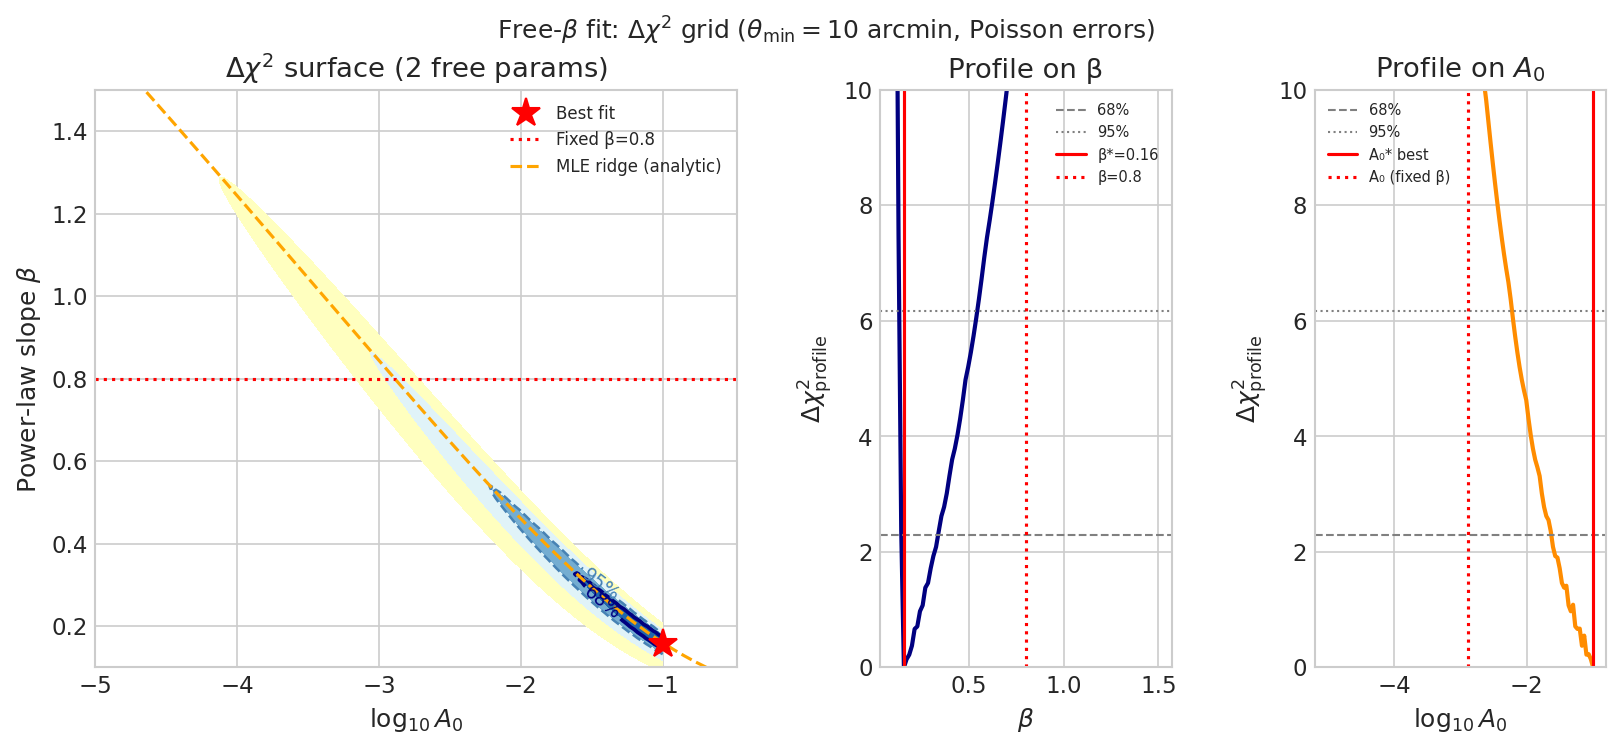

In [13]:
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[2.2, 1, 1], wspace=0.35)

ax_2d  = fig.add_subplot(gs[0])
ax_b   = fig.add_subplot(gs[1])
ax_a0  = fig.add_subplot(gs[2])

# --- 2D contour plot ---
lev68, lev95 = 2.30, 6.17
cf = ax_2d.contourf(log10A0_grid, beta_grid, delta_chi2,
                    levels=[0, lev68, lev95, 15, 30],
                    colors=['#2166ac', '#74add1', '#e0f3f8', '#ffffbf', 'white'])
cs68 = ax_2d.contour(log10A0_grid, beta_grid, delta_chi2,
                     levels=[lev68], colors='navy',  linewidths=1.8)
cs95 = ax_2d.contour(log10A0_grid, beta_grid, delta_chi2,
                     levels=[lev95], colors='steelblue', linewidths=1.2, linestyles='--')

# Best-fit point
ax_2d.plot(np.log10(A0_best), beta_best, 'r*', ms=14, zorder=5, label='Best fit')
# Fiducial β line
ax_2d.axhline(BETA_FID, color='red', ls=':', lw=1.5, label=f'Fixed β={BETA_FID}')
# Analytic MLE curve
valid_mle = A0_mle_curve > 0
ax_2d.plot(np.log10(A0_mle_curve[valid_mle]), beta_grid[valid_mle],
           color='orange', lw=1.5, ls='--', label='MLE ridge (analytic)')

ax_2d.set_xlabel(r'$\log_{10} A_0$')
ax_2d.set_ylabel(r'Power-law slope $\beta$')
ax_2d.set_title(r'$\Delta\chi^2$ surface (2 free params)')
ax_2d.clabel(cs68, fmt={lev68: '68%'}, fontsize=9)
ax_2d.clabel(cs95, fmt={lev95: '95%'}, fontsize=9)
ax_2d.legend(fontsize=8)

# --- Profile likelihood on β: minimize over A0 for each beta ---
prof_beta = np.min(delta_chi2, axis=1)   # shape (N_BETA,)
ax_b.plot(beta_grid, prof_beta, color='navy', lw=2)
ax_b.axhline(lev68, color='gray', ls='--', lw=1, label='68%')
ax_b.axhline(lev95, color='gray', ls=':',  lw=1, label='95%')
ax_b.axvline(beta_best, color='red', ls='-', lw=1.5, label=f'β*={beta_best:.2f}')
ax_b.axvline(BETA_FID,  color='red', ls=':', lw=1.5, label=f'β={BETA_FID}')
ax_b.set_xlabel(r'$\beta$')
ax_b.set_ylabel(r'$\Delta\chi^2_{\rm profile}$')
ax_b.set_title('Profile on β')
ax_b.set_ylim(0, 10)
ax_b.legend(fontsize=7)

# --- Profile likelihood on A0: minimize over beta for each A0 ---
prof_A0 = np.min(delta_chi2, axis=0)   # shape (N_A0,)
ax_a0.plot(log10A0_grid, prof_A0, color='darkorange', lw=2)
ax_a0.axhline(lev68, color='gray', ls='--', lw=1, label='68%')
ax_a0.axhline(lev95, color='gray', ls=':',  lw=1, label='95%')
ax_a0.axvline(np.log10(A0_best),     color='red', ls='-', lw=1.5, label=f'A₀* best')
ax_a0.axvline(np.log10(A0_FID := 1.28e-3), color='red', ls=':', lw=1.5, label=f'A₀ (fixed β)')
ax_a0.set_xlabel(r'$\log_{10} A_0$')
ax_a0.set_ylabel(r'$\Delta\chi^2_{\rm profile}$')
ax_a0.set_title(r'Profile on $A_0$')
ax_a0.set_ylim(0, 10)
ax_a0.legend(fontsize=7)

plt.suptitle(r'Free-$\beta$ fit: $\Delta\chi^2$ grid ($\theta_{\rm min}=10$ arcmin, Poisson errors)',
             fontsize=12)
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'free_beta_chi2_grid.pdf'),
            bbox_inches='tight')
plt.show()

In [14]:
# --- Read off 68% confidence interval on beta from profile ---
# Find where profile crosses Δχ²=2.30
from scipy.interpolate import interp1d

prof_interp = interp1d(beta_grid, prof_beta, kind='cubic')
# Left and right crossings
try:
    from scipy.optimize import brentq
    # Left of minimum
    if prof_beta[0] > lev68:
        beta_lo68 = brentq(lambda b: prof_interp(b) - lev68, beta_grid[0], beta_best)
    else:
        beta_lo68 = beta_grid[0]
    # Right of minimum
    if prof_beta[-1] > lev68:
        beta_hi68 = brentq(lambda b: prof_interp(b) - lev68, beta_best, beta_grid[-1])
    else:
        beta_hi68 = beta_grid[-1]
    # 95%
    beta_lo95 = brentq(lambda b: prof_interp(b) - lev95, beta_grid[0], beta_best) if prof_beta[0] > lev95 else beta_grid[0]
    beta_hi95 = brentq(lambda b: prof_interp(b) - lev95, beta_best, beta_grid[-1]) if prof_beta[-1] > lev95 else beta_grid[-1]
except Exception as e:
    print(f'Could not find crossing: {e}')
    beta_lo68, beta_hi68 = np.nan, np.nan
    beta_lo95, beta_hi95 = np.nan, np.nan

# Propagate best-fit β → b using free-β Limber inversion
gamma_best   = beta_best + 1.0
H_gamma_best = limber_h_gamma(z_fp, gamma_best, cosmo, dz=0.05)
r0_best      = a0_to_r0(A0_best, gamma_best, H_gamma_best)
b_best       = linear_bias(r0_best, z_eff, gamma_best, sigma8, cosmo)

print('=' * 65)
print('FREE-β RESULT (2D χ² grid, θ_min=10 arcmin, Poisson errors)')
print('=' * 65)
print(f'  Best-fit β   = {beta_best:.3f}')
print(f'  68% CI on β  = [{beta_lo68:.3f}, {beta_hi68:.3f}]')
print(f'  95% CI on β  = [{beta_lo95:.3f}, {beta_hi95:.3f}]')
print()
print(f'  Best-fit A₀  = {A0_best:.4e}')
print(f'  Best-fit r₀  = {r0_best:.2f} Mpc')
print(f'  Best-fit b   = {b_best:.2f}')
print()
print(f'  Fixed-β=0.8 result:  b = {B_FID:.2f} [{B_FID_LO:.2f}, {B_FID_HI:.2f}]')
print(f'  Free-β best fit:     b = {b_best:.2f}')
print(f'  Δb = {abs(b_best - B_FID):.2f}')
print()
if not np.isnan(beta_lo68):
    print(f'  → β = {beta_best:.2f} +{beta_hi68 - beta_best:.2f} / -{beta_best - beta_lo68:.2f}  (68% profile CI)')
    print(f'    Fiducial β=0.8 is {"within" if beta_lo68 < 0.8 < beta_hi68 else "outside"} the 68% CI')
print('=' * 65)

FREE-β RESULT (2D χ² grid, θ_min=10 arcmin, Poisson errors)
  Best-fit β   = 0.157
  68% CI on β  = [0.143, 0.338]
  95% CI on β  = [0.131, 0.544]

  Best-fit A₀  = 1.0000e-01
  Best-fit r₀  = 18.99 Mpc
  Best-fit b   = 3.71

  Fixed-β=0.8 result:  b = 6.60 [6.20, 6.96]
  Free-β best fit:     b = 3.71
  Δb = 2.89

  → β = 0.16 +0.18 / -0.01  (68% profile CI)
    Fiducial β=0.8 is outside the 68% CI
